In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

In [2]:
#load dataset
df = pd.read_csv(r'C:\Users\LENOVO\Documents\Datasets\quick_commerce_data_raw.csv')

In [3]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [4]:
#dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [5]:
#summary statistics
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,965000.000000,953000.000000,1000000.000000,895863.000000
mean,1.500000e+06,38.470387,571.643584,16.452412,7.750231,9.998317,3.042072,0.400883,3.749257
std,2.886753e+05,12.118520,382.784520,6.257172,4.186665,5.478725,1.186872,0.490078,0.722121
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.250001e+06,28.000000,287.840150,12.368000,4.130000,5.000000,2.000000,0.000000,3.100000
50%,1.500000e+06,38.000000,531.324600,16.342000,7.740000,10.000000,3.000000,0.000000,3.700000
75%,1.750000e+06,49.000000,796.182500,20.196000,11.380000,15.000000,4.000000,1.000000,4.400000
max,2.000000e+06,59.000000,13877.325000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [6]:
#check for missing values
df.isna().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [7]:
#To show the records which contain any or all null values
df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
6,1000007,Blinkit,Bengluru,37,516.86480,18.476,12.46,19.0,Snacks,Debit Card,2.8,0,NaN
17,1000018,Zepto,Delhi,23,1041.42975,5.000,14.74,18.0,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.89860,17.804,11.34,7.0,Beverages,Credit Card,2.7,1,3.6
22,1000023,Jio Mart,Delhi,48,50.00000,8.498,0.83,3.0,Snacks,Cash on Delivery,3.1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89250,18.820,14.70,NaN,Household,Wallet,3.1,1,4.9
999975,1999976,Amazon Now,Bengluru,34,515.89380,21.294,10.49,10.0,Fruits & Vegetables,Wallet,NaN,1,3.0
999981,1999982,Amazon Now,NaN,33,939.34470,21.080,11.80,18.0,Dairy,Wallet,3.2,1,4.4
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00000,13.386,2.31,2.0,Groceries,Wallet,NaN,0,3.2


## Remove rows having null values

In [8]:
#drop rows having missing values in 'city' column
df = df.dropna(subset = ['City'])

In [9]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [10]:
df.shape

(948000, 13)

In [11]:
#check missing values again
df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                33228
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [12]:
x = df['Items_Count'].mode()
x

0    19.0
Name: Items_Count, dtype: float64

In [13]:
#fill missing values with the mode
df['Items_Count'].fillna(x[0], inplace = True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\1816824460.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Items_Count'].fillna(x[0], inplace = True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\1816824460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Items_Count'].fillna(x[0], inplace = True)


In [14]:
#check missing values again
df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating            44575
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

## Fill null values with group wise mean and median

In [15]:
#use group wise mean imputation
df['Customer_Rating'] = df.groupby("Company")['Customer_Rating'].transform(lambda x:x.fillna(x.mean()))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\1987051417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer_Rating'] = df.groupby("Company")['Customer_Rating'].transform(lambda x:x.fillna(x.mean()))


In [16]:
df['Customer_Rating']

0         2.1
1         2.3
2         3.3
3         5.0
4         3.7
         ... 
999995    4.2
999996    4.1
999997    3.4
999998    4.0
999999    4.1
Name: Customer_Rating, Length: 948000, dtype: float64

In [17]:
#check missing values again
df.isna().sum()

Order_ID                       0
Company                        0
City                           0
Customer_Age                   0
Order_Value                    0
Delivery_Time_Min              0
Distance_Km                    0
Items_Count                    0
Product_Category               0
Payment_Method                 0
Customer_Rating                0
Discount_Applied               0
Delivery_Partner_Rating    98694
dtype: int64

In [18]:
df['Delivery_Partner_Rating'] = df.groupby("Delivery_Time_Min")['Delivery_Partner_Rating'].transform(lambda y:y.fillna(y.mean()))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\3260677074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Partner_Rating'] = df.groupby("Delivery_Time_Min")['Delivery_Partner_Rating'].transform(lambda y:y.fillna(y.mean()))


In [19]:
df['Delivery_Partner_Rating']

0         3.2
1         3.2
2         3.8
3         5.0
4         4.8
         ... 
999995    2.8
999996    3.5
999997    4.6
999998    4.5
999999    4.8
Name: Delivery_Partner_Rating, Length: 948000, dtype: float64

In [20]:
#check missing values again
df.isna().sum()

Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [21]:
df.shape

(948000, 13)

In [22]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8


In [23]:
#check missing values again
df.isna().sum()

Order_ID                    0
Company                     0
City                        0
Customer_Age                0
Order_Value                 0
Delivery_Time_Min           0
Distance_Km                 0
Items_Count                 0
Product_Category            0
Payment_Method              0
Customer_Rating             0
Discount_Applied            0
Delivery_Partner_Rating    76
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 948000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 948000 non-null  int64  
 1   Company                  948000 non-null  object 
 2   City                     948000 non-null  object 
 3   Customer_Age             948000 non-null  int64  
 4   Order_Value              948000 non-null  float64
 5   Delivery_Time_Min        948000 non-null  float64
 6   Distance_Km              948000 non-null  float64
 7   Items_Count              948000 non-null  float64
 8   Product_Category         948000 non-null  object 
 9   Payment_Method           948000 non-null  object 
 10  Customer_Rating          948000 non-null  float64
 11  Discount_Applied         948000 non-null  int64  
 12  Delivery_Partner_Rating  947924 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.3+ MB


## Remove outliers

<Axes: >

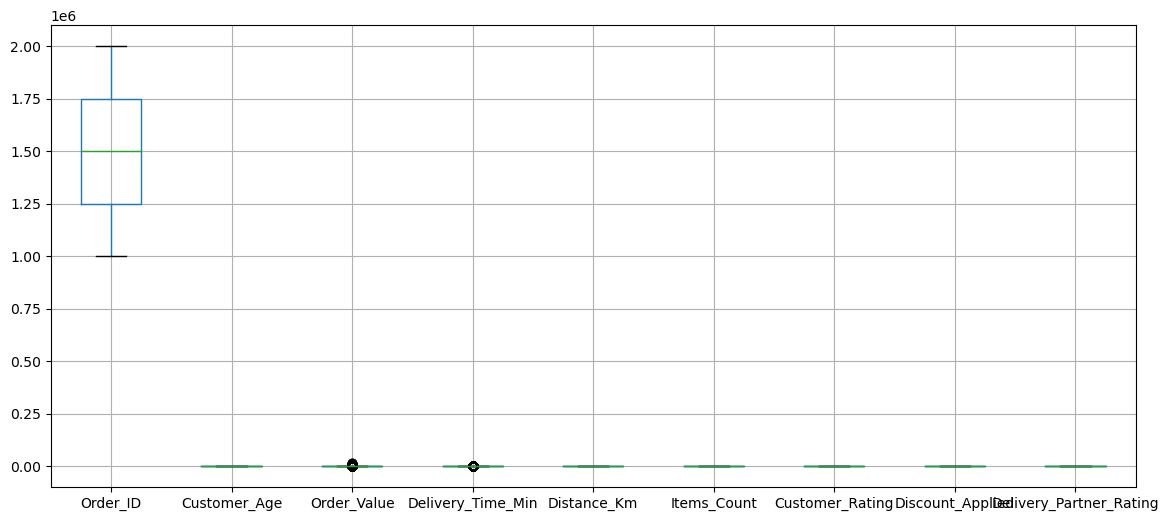

In [25]:
#Box plot
plt.figure(figsize=(14,6))
df.boxplot()

<Axes: >

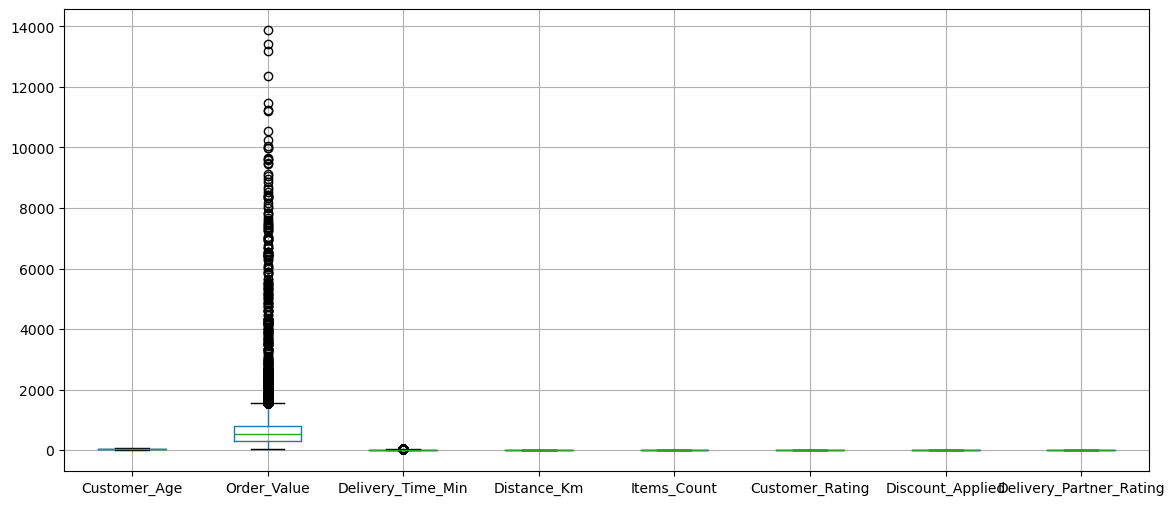

In [26]:
#Box plot without 'order_id' column
plt.figure(figsize=(14,6))
df.drop(columns = ['Order_ID']).boxplot()

In [27]:
#1)perecntile (capping) method
# df['Order_Value'] = df['Order_Value'].clip(upper = 2500)

In [28]:
#2)filtering method
df =  df[df['Order_Value'] <= 2500]
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,19.0,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


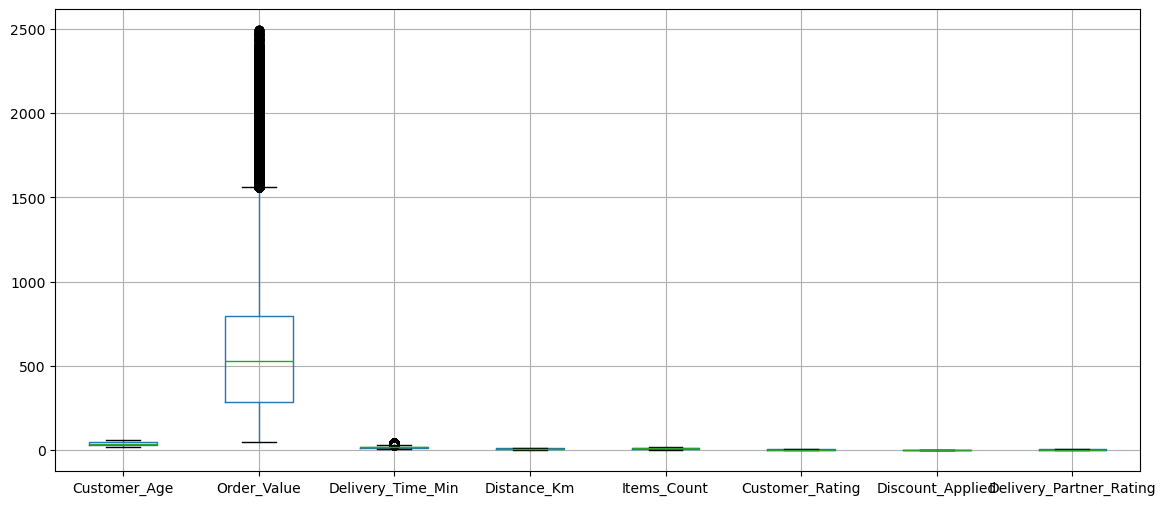

In [29]:
#Box plot without 'order_id' column
plt.figure(figsize=(14,6))
df.drop(columns = ['Order_ID']).boxplot()
plt.show()

<Axes: >

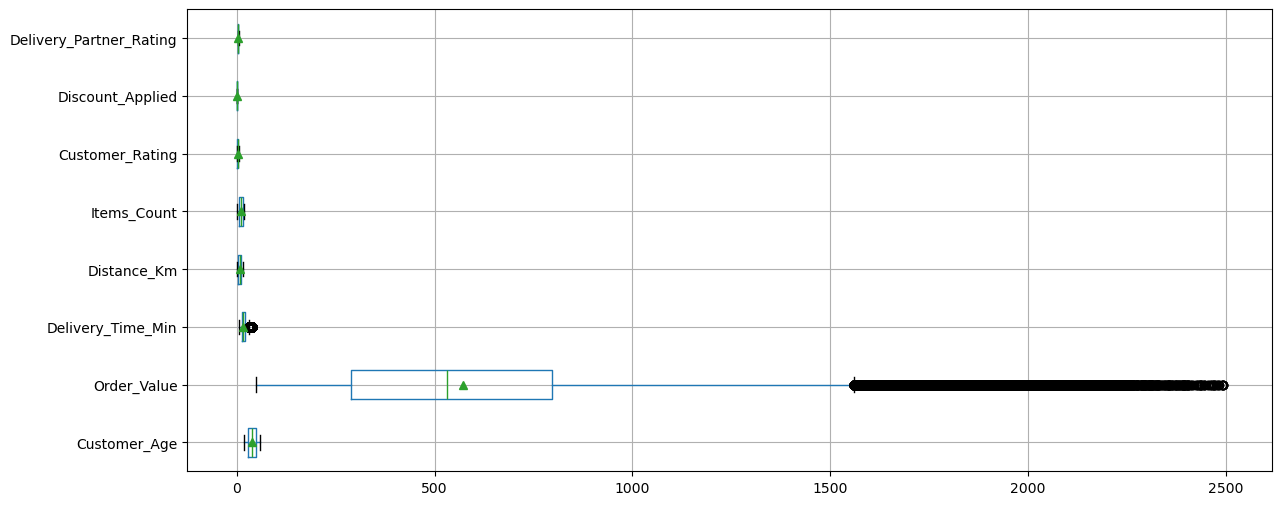

In [30]:
#Box plot without 'order_id' column
plt.figure(figsize=(14,6))
df.drop(columns = ['Order_ID']).boxplot(vert = False, showmeans = True)

In [31]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947676.000000
mean,1.500028e+06,38.471165,570.912385,16.502070,7.750046,10.313292,3.042843,0.400786,3.749173
std,2.887273e+05,12.118982,374.174789,6.330106,4.186990,5.630770,1.161112,0.490058,0.684392
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.500000
25%,1.249939e+06,28.000000,287.923000,12.362000,4.130000,5.000000,2.100000,0.000000,3.200000
50%,1.500026e+06,38.000000,531.674100,16.384000,7.750000,10.000000,3.015637,0.000000,3.753051
75%,1.750145e+06,49.000000,796.556650,20.302000,11.380000,15.000000,4.000000,1.000000,4.300000
max,2.000000e+06,59.000000,2492.435250,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  float64
 5   Delivery_Time_Min        947752 non-null  float64
 6   Distance_Km              947752 non-null  float64
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  float64
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947676 non-null  float64
dtypes: float64(6), int64(3), object(4)
memory usage: 101.2+ MB


## change column data type

In [33]:
#change the datatype of 'order_ID'
df['Order_ID'] = df['Order_ID'].astype(str)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\417072887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_ID'] = df['Order_ID'].astype(str)


In [34]:
#round-off the float values
df['Order_Value'] = np.round(df['Order_Value'])
df['Delivery_Time_Min'] = np.round(df['Delivery_Time_Min'])
df['Distance_Km'] = np.round(df['Distance_Km'], 1)
df['Customer_Rating'] = np.round(df['Customer_Rating'])
df['Delivery_Partner_Rating'] = np.round(df['Delivery_Partner_Rating'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\3604073576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Value'] = np.round(df['Order_Value'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\3604073576.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Time_Min'] = np.round(df['Delivery_Time_Min'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\3604073576.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [35]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.0,19.0,12.0,12.0,Dairy,Wallet,2.0,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007.0,20.0,12.7,10.0,Snacks,Cash on Delivery,2.0,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212.0,17.0,4.8,19.0,Personal Care,Cash on Delivery,3.0,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179.0,6.0,6.4,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.0,12.0,2.4,13.0,Household,Wallet,4.0,0,5.0


In [36]:
#change the data type of float to integer
df['Order_Value'] = df['Order_Value'].astype(int)
df['Delivery_Time_Min'] = df['Delivery_Time_Min'].astype(int)
df['Distance_Km'] = df['Distance_Km'].astype(int)
df['Customer_Rating'] = df['Customer_Rating'].astype(int)
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].astype(int)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\2535730599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Value'] = df['Order_Value'].astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\2535730599.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Time_Min'] = df['Delivery_Time_Min'].astype(int)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\2535730599.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [37]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0


In [38]:
#dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947752 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  object 
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Order_Value              947752 non-null  int64  
 5   Delivery_Time_Min        947752 non-null  int64  
 6   Distance_Km              947752 non-null  int64  
 7   Items_Count              947752 non-null  float64
 8   Product_Category         947752 non-null  object 
 9   Payment_Method           947752 non-null  object 
 10  Customer_Rating          947752 non-null  int64  
 11  Discount_Applied         947752 non-null  int64  
 12  Delivery_Partner_Rating  947676 non-null  float64
dtypes: float64(2), int64(6), object(5)
memory usage: 101.2+ MB


## >>Business Questions<<
### Q1) which quick commerce platform has the highest revenue

In [39]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0


In [40]:
#group data - calculate total order value for companies
company_revenue = df.groupby('Company')['Order_Value'].sum()
company_revenue

Company
Amazon Now          65832504
Big Basket          67884762
Blinkit             72499575
Dunzo               64007579
Flipkart Minutes    66998289
Jio Mart            57112860
Swiggy Instamart    76407756
Zepto               70339672
Name: Order_Value, dtype: int64

In [41]:
#sort grouped data
company_revenue.sort_values()

Company
Jio Mart            57112860
Dunzo               64007579
Amazon Now          65832504
Flipkart Minutes    66998289
Big Basket          67884762
Zepto               70339672
Blinkit             72499575
Swiggy Instamart    76407756
Name: Order_Value, dtype: int64

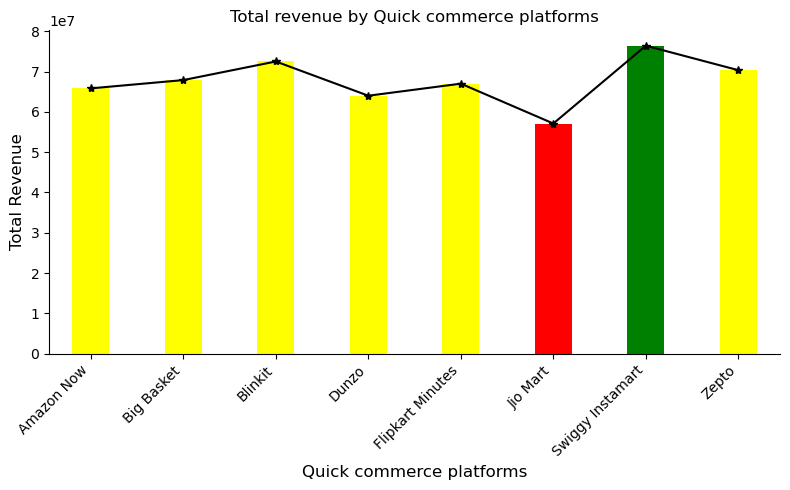

In [42]:
#Bar chart and the line chart
plt.figure(figsize = (8,5))

#find max and min revenue
max_val = company_revenue.max()
min_val = company_revenue.min()

#assign color based on the value
colors = ['green' if val == max_val else
          'red' if val == min_val else
          'yellow'
           for val in company_revenue
         ]
#draw bar and line chart at once 
company_revenue.plot(kind = 'bar', color = colors, width = 0.4)
company_revenue.plot(kind = 'line', color = 'black', marker = '*')
plt.xlabel("Quick commerce platforms", fontsize = 12)
plt.ylabel("Total Revenue", fontsize = 12)
plt.title("Total revenue by Quick commerce platforms")
plt.xticks(rotation=45, ha = "right")

ax = plt.gca() #gca - get current axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Q2) which platform has the highest averahe order value(AOV)?

In [43]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0


In [44]:
# group data - calculate the average order value for companies
AOV = df.groupby('Company')['Order_Value'].mean().sort_values()
AOV

Company
Jio Mart            482.914592
Dunzo               540.317053
Amazon Now          557.510429
Flipkart Minutes    563.176472
Big Basket          575.065542
Zepto               593.258314
Blinkit             609.819198
Swiggy Instamart    644.927250
Name: Order_Value, dtype: float64

In [45]:
type(AOV)

pandas.core.series.Series

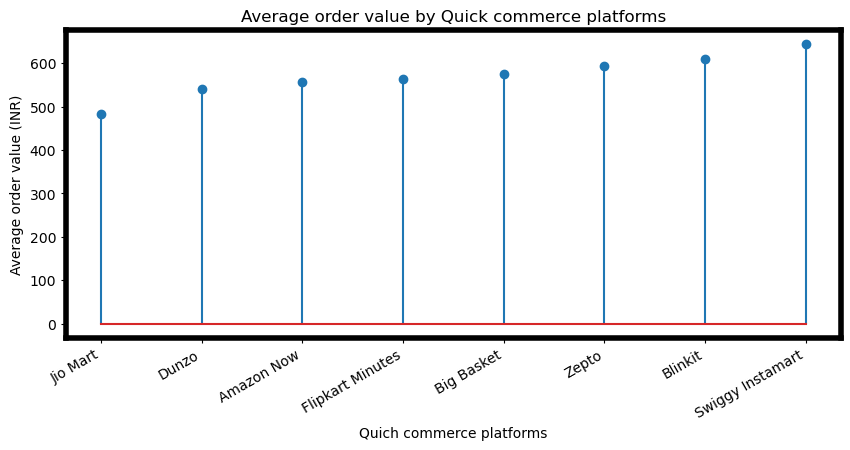

In [46]:
#stem chart
plt.figure(figsize = (10,4))
plt.stem(AOV.index, AOV.values)    # stem chart
plt.xlabel("Quich commerce platforms")
plt.ylabel("Average order value (INR)")
plt.title("Average order value by Quick commerce platforms")
plt.xticks(rotation=30, ha = 'right')

ax = plt.gca()
#highlight all four borders
ax.spines['top'].set_linewidth(4)
ax.spines['right'].set_linewidth(4)
ax.spines['left'].set_linewidth(4)
ax.spines['bottom'].set_linewidth(4)
plt.show()

## Q3) how does customer rating vary across platforms

In [47]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0


In [48]:
# group data - calculate average rating for companies
df.groupby('Company')['Customer_Rating'].mean().sort_values()

Company
Dunzo               2.428024
Jio Mart            2.819747
Amazon Now          2.913417
Flipkart Minutes    3.016316
Big Basket          3.097902
Zepto               3.203062
Swiggy Instamart    3.279443
Blinkit             3.580762
Name: Customer_Rating, dtype: float64

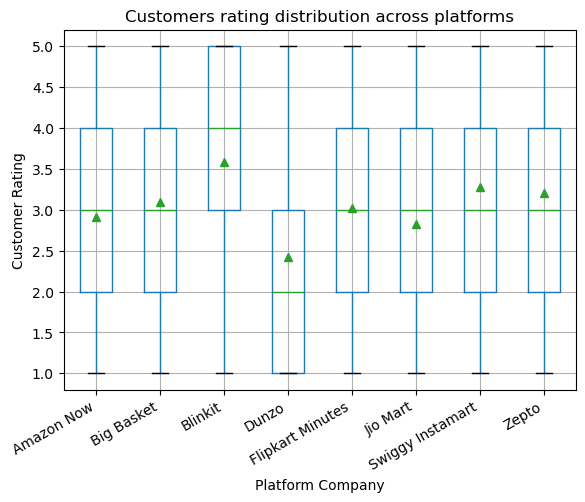

In [49]:
#boxplot
df.boxplot(column = 'Customer_Rating', by = 'Company', showmeans = True)

plt.suptitle("")  # removing default pandas title
plt.tight_layout

plt.title("Customers rating distribution across platforms")
plt.xlabel("Platform Company")
plt.ylabel("Customer Rating")
plt.xticks(rotation = 30, ha = 'right')
plt.grid(True)
plt.show()

In [50]:
#group data
grouped_rating = df.groupby(['Company', 'Customer_Rating']).size().unstack(fill_value=0)
grouped_rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,15977,30351,30866,29697,11192
Big Basket,10143,30339,31020,30908,15637
Blinkit,1060,25553,25561,36708,30005
Dunzo,29818,36280,25377,25818,1170
Flipkart Minutes,12549,30786,31225,30985,13420
Jio Mart,18513,30515,31083,30089,8067
Swiggy Instamart,5000,30278,31039,30931,21227
Zepto,7618,29763,31367,30559,19258


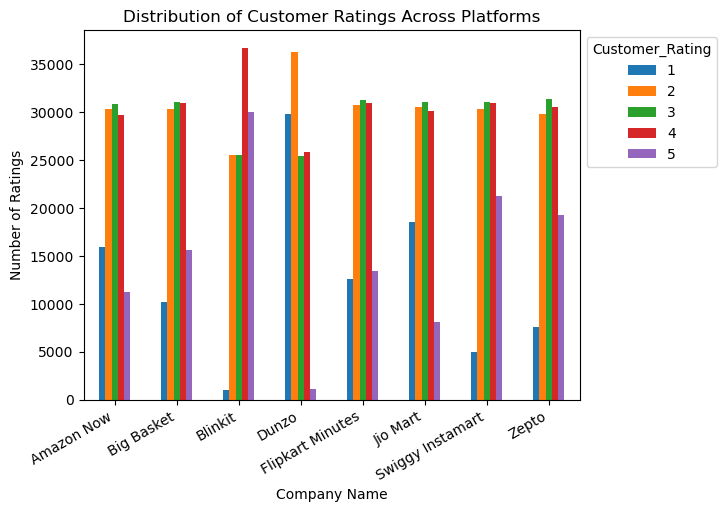

In [51]:
#bar chart forthe group ratings 
grouped_rating.plot(kind = 'bar')
plt.xlabel("Company Name")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Customer Ratings Across Platforms")
plt.legend(title = 'Customer_Rating', bbox_to_anchor = (1,1), loc = 'upper left')
plt.xticks(rotation=30, ha='right')
plt.show()

## Q4) Does 'delivery time'  affects the 'delivery partner rating'?

In [52]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0


In [53]:
df['Delivery_Time_Min'].mean()

np.float64(16.506619875241626)

In [54]:
df['Delivery_Partner_Rating'].mean()

np.float64(3.800278787264846)

In [55]:
# calculate average rating for delivery time
x = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()

In [56]:
df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating'])

np.float64(-0.0028414914370014145)

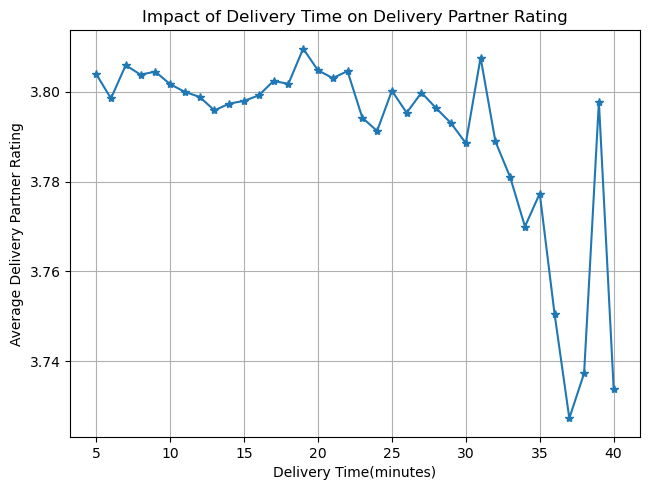

In [57]:
#line chart
x.plot(marker = '*')
plt.tight_layout()
plt.xlabel("Delivery Time(minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")
plt.grid(True)

plt.show()

In [58]:
#syntax : pd.cut(col_name, bins, labels)
df['Delivery_Time_Bucket'] = pd.cut(
                                    df['Delivery_Time_Min'], 
                                    bins = (0,10,20,30,40,50), 
                                    labels = ("Very fast delivery","Fast delivery", "Normal delivery", "Slow delivery", "Very slow delivery"))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\565868999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Time_Bucket'] = pd.cut(


In [59]:
#syntax : pd.cut(col_name, bins, labels)
df['Delivery_Time_Bucket'] = pd.cut(
                                    df['Delivery_Time_Min'], 
                                    bins = (0,10,20,30,40,50), 
                                    labels = ("Very fast delivery","Fast delivery", "Normal delivery", "Slow delivery", "Very slow delivery"))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\565868999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Delivery_Time_Bucket'] = pd.cut(


In [60]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0,Fast delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0,Fast delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0,Fast delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0,Very fast delivery
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0,Fast delivery


In [61]:
# calculate average rating for delivery time
bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()
bucket_avg

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\4013435410.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()


Delivery_Time_Bucket
Very fast delivery    3.803226
Fast delivery         3.800835
Normal delivery       3.798345
Slow delivery         3.782950
Very slow delivery         NaN
Name: Delivery_Partner_Rating, dtype: float64

In [62]:
df['Delivery_Time_Min'].max()

40

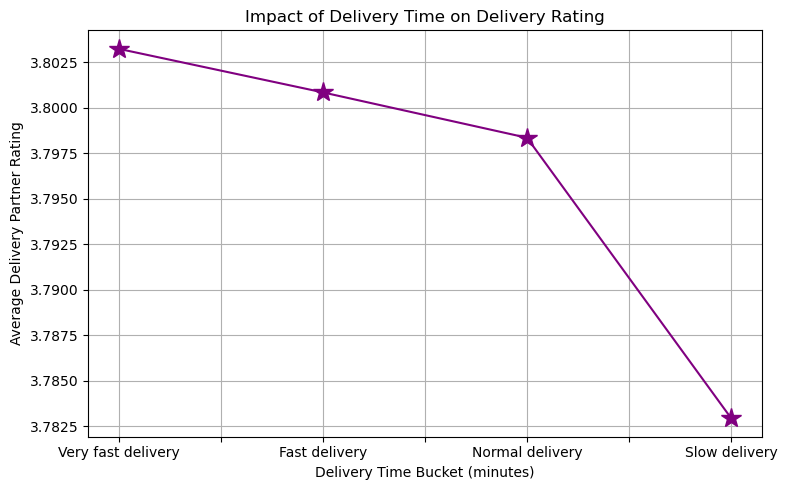

In [63]:
plt.figure(figsize = (8,5))
bucket_avg.plot(marker='*', markersize=15, color='purple')
plt.xlabel("Delivery Time Bucket (minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Rating")
plt.grid(True)
plt.tight_layout()
plt.show()


## Q5) What is the most popular product category on swiggy instamrt, for the people of age between 30-40, in Mumbai?


In [64]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0,Fast delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0,Fast delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0,Fast delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0,Very fast delivery
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0,Fast delivery


In [65]:
#Filtering
df_pc = df[
          (df['Company'] == 'Swiggy Instamart')&
          ((df['Customer_Age']>= 30) & (df['Customer_Age'] <= 40)) &
          (df['City'] == 'Mumbai')
          ]
df_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
536,1000537,Swiggy Instamart,Mumbai,38,1157,14,5,18.0,Beverages,Cash on Delivery,4,1,4.0,Fast delivery
909,1000910,Swiggy Instamart,Mumbai,32,926,20,14,3.0,Dairy,UPI,2,0,5.0,Fast delivery
1203,1001204,Swiggy Instamart,Mumbai,37,234,19,7,6.0,Dairy,Debit Card,5,0,4.0,Fast delivery
2918,1002919,Swiggy Instamart,Mumbai,31,423,15,4,10.0,Dairy,Cash on Delivery,2,0,3.0,Fast delivery
4251,1004252,Swiggy Instamart,Mumbai,36,50,15,2,12.0,Dairy,Credit Card,3,0,3.0,Fast delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998562,1998563,Swiggy Instamart,Mumbai,40,843,20,11,3.0,Personal Care,Cash on Delivery,4,0,4.0,Fast delivery
999242,1999243,Swiggy Instamart,Mumbai,32,747,13,2,12.0,Household,UPI,5,1,5.0,Fast delivery
999258,1999259,Swiggy Instamart,Mumbai,35,50,18,7,4.0,Personal Care,Debit Card,5,0,5.0,Fast delivery
999680,1999681,Swiggy Instamart,Mumbai,39,375,19,8,6.0,Household,Wallet,2,0,4.0,Fast delivery


In [66]:
#Most popular category
df_pc['Product_Category'].value_counts()

Product_Category
Dairy                  407
Groceries              384
Fruits & Vegetables    375
Snacks                 374
Household              372
Personal Care          343
Beverages              332
Name: count, dtype: int64

In [67]:
df_pc['Product_Category'].value_counts().max()

407

## Q6) Which cities should these company expand into based on performance

In [68]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0,Fast delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0,Fast delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0,Fast delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0,Very fast delivery
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0,Fast delivery


In [69]:
#group data and apply aggregate functions
city_perf = df.groupby(['Company', 'City']).agg( Total_orders = ('Order_ID', 'count'),
                                     Avg_rating = ("Customer_Rating",'mean'),
                                     Avg_delivery_time= ("Delivery_Time_Min", 'mean'),
                                     Total_Revenue=("Order_Value", 'sum')
                                   ).reset_index()
city_perf

,Company,City,Total_orders,Avg_rating,Avg_delivery_time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.896666,18.167388,5469439
1,Amazon Now,Bengluru,9905,3.387683,19.183342,5629936
2,Amazon Now,Chennai,9847,2.904032,18.138722,5363559
3,Amazon Now,Delhi,9918,2.989716,8.294616,5891026
4,Amazon Now,Gurgaon,9797,2.921711,18.166173,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.112213,13.145278,4621428
92,Zepto,Kolkata,9825,3.173028,8.302901,5776955
93,Zepto,Mumbai,9861,3.412230,10.152013,6046485
94,Zepto,Noida,10070,3.206653,8.297617,7070769


In [70]:
#Filtering best cities based on given conditions
best_cities = city_perf[
                       (city_perf['Avg_rating'] >= 3.5) &
                       (city_perf['Avg_delivery_time'] <= 15) &
                       (city_perf['Total_orders'] > city_perf['Total_orders'].median() )
                       ]
best_cities

,Company,City,Total_orders,Avg_rating,Avg_delivery_time,Total_Revenue
24,Blinkit,Amritsar,9932,3.589106,14.199154,6006361
26,Blinkit,Chennai,9876,3.580903,14.135581,5921870
28,Blinkit,Gurgaon,10078,3.579381,14.199345,7374774
32,Blinkit,Kolkata,10004,3.566873,14.142743,6003384
35,Blinkit,Pune,9908,3.583266,14.164110,5930415
85,Zepto,Bengluru,9971,3.598636,9.198977,6041668


In [71]:
best_cities[['Company','City']]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


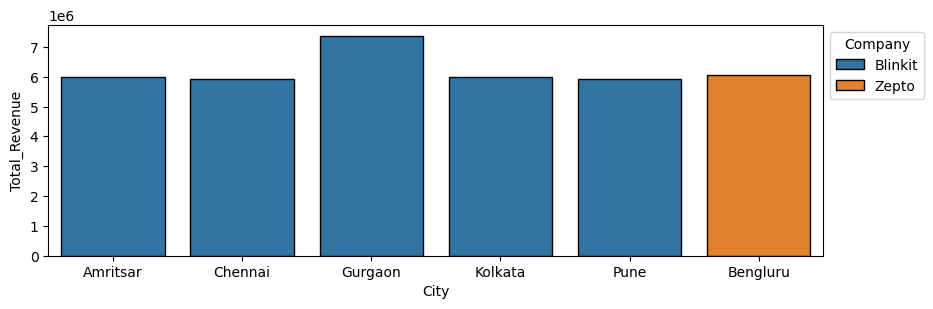

In [72]:
plt.figure(figsize = (10,3))
sns.barplot(data = best_cities, x='City', y='Total_Revenue', hue='Company', edgecolor='black')
plt.legend( title='Company', bbox_to_anchor = (1,1))
plt.show()

## Q7) Are discounts increasing order volume or just decreasing revenue

In [73]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0,Fast delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0,Fast delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0,Fast delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0,Very fast delivery
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0,Fast delivery


In [74]:
#count the number of orders with and without discounts
df['Discount_Applied'].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [75]:
#group data - calculate average order value
dis_order_value = df.groupby('Discount_Applied')['Order_Value'].mean()
dis_order_value

Discount_Applied
0    476.417152
1    712.190830
Name: Order_Value, dtype: float64

In [76]:
#group data - calculate the sum of the items count
dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()
dis_items_count

Discount_Applied
0    5854258.0
1    3920185.0
Name: Items_Count, dtype: float64

In [77]:
x = df['Discount_Applied'].unique()
print(x)

[1 0]


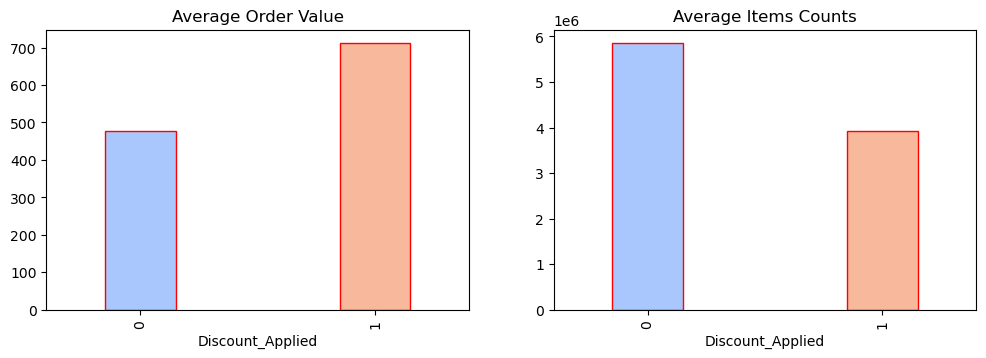

In [78]:
plt.figure(figsize=(12,8))

#use gradient colors
colors = sns.color_palette("coolwarm", len(x))
plt.subplot(2,2,1)
dis_order_value.plot(kind='bar', width = 0.3, edgecolor = 'red', color = colors)
plt.title("Average Order Value")

plt.subplot(2,2,2)
dis_items_count.plot(kind='bar', width = 0.3, edgecolor = 'red', color = colors)
plt.title("Average Items Counts")
plt.show()

## Q8) Which company has the best operational efficiency(Delivery time vs Order volume)?

In [79]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12,12.0,Dairy,Wallet,2,1,3.0,Fast delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12,10.0,Snacks,Cash on Delivery,2,0,3.0,Fast delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4,19.0,Personal Care,Cash on Delivery,3,0,4.0,Fast delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6,2.0,Dairy,Credit Card,5,1,5.0,Very fast delivery
4,1000005,Dunzo,Mumbai,44,586,12,2,13.0,Household,Wallet,4,0,5.0,Fast delivery


In [80]:
#group data and apply aggregate functions
company_efficiency = df.groupby('Company').agg(
                         Total_orders = ('Order_ID', 'count'),
                         Avg_delivery_time = ('Delivery_Time_Min', 'mean')
                         ).reset_index()
company_efficiency

,Company,Total_orders,Avg_delivery_time
0,Amazon Now,118083,18.984155
1,Big Basket,118047,18.027345
2,Blinkit,118887,15.121771
3,Dunzo,118463,14.177060
4,Flipkart Minutes,118965,17.045080
5,Jio Mart,118267,23.013224
6,Swiggy Instamart,118475,16.072690
7,Zepto,118565,9.644313


In [81]:
#Normalize value for fair comparison
from sklearn.preprocessing import MinMaxScaler

#scaling both columns to the same range(0 to 1) so that they can be fairly compared and combined
scaler = MinMaxScaler()   # creating a scaling object..
company_efficiency[['Total_Orders_Scaled', 'Avg_Delivery_Time_Scaled']] = scaler.fit_transform(company_efficiency[['Total_orders', 'Avg_delivery_time']])

In [82]:
company_efficiency

,Company,Total_orders,Avg_delivery_time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Amazon Now,118083,18.984155,0.039216,0.698624
1,Big Basket,118047,18.027345,0.000000,0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716
3,Dunzo,118463,14.177060,0.453159,0.339051
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580
5,Jio Mart,118267,23.013224,0.239651,1.000000
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845
7,Zepto,118565,9.644313,0.564270,0.000000


In [83]:
#Efficiency score (higher orders, lower time)
company_efficiency['Efficiency_score'] = company_efficiency['Total_Orders_Scaled'] - company_efficiency['Avg_Delivery_Time_Scaled']

In [84]:
company_efficiency

,Company,Total_orders,Avg_delivery_time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_score
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270


In [85]:
#sort by best efficiency

eff = company_efficiency.sort_values(by = 'Efficiency_score', ascending = False)
eff

,Company,Total_orders,Avg_delivery_time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


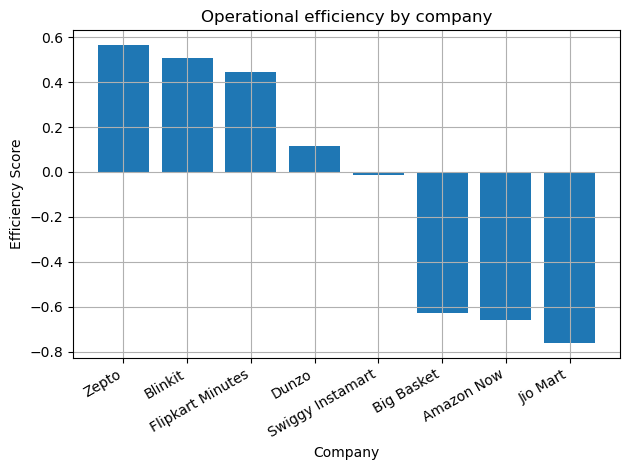

In [86]:
plt.bar(eff['Company'], eff['Efficiency_score'])
plt.xlabel("Company")
plt.ylabel("Efficiency Score")
plt.title("Operational efficiency by company")
plt.xticks(rotation = 30, ha = 'right')
plt.grid(True)
plt.tight_layout()
plt.show()

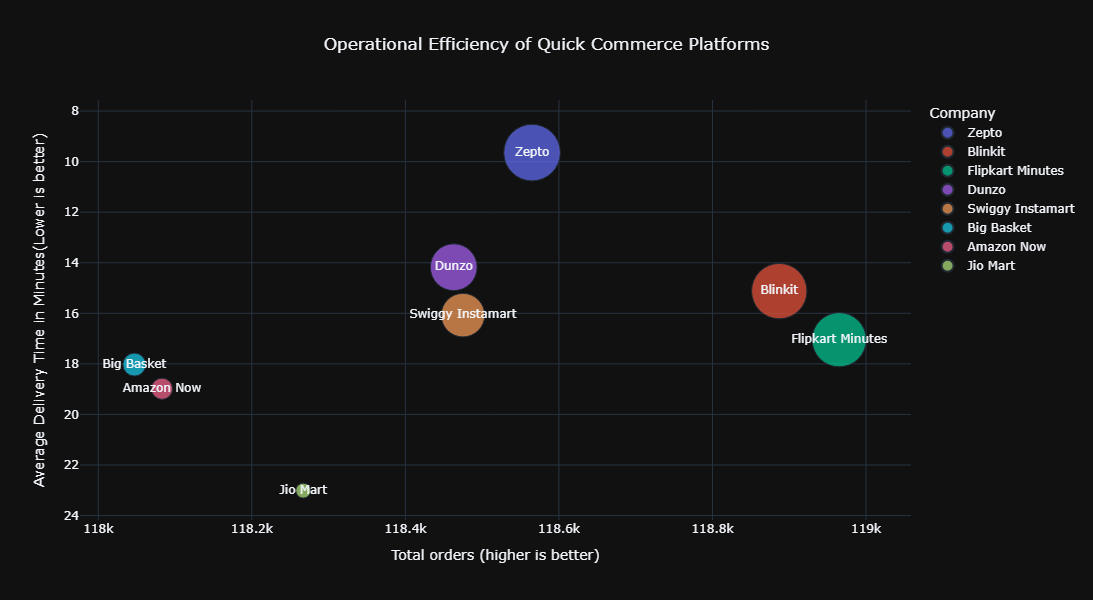

In [87]:
#use plotly library - scatter bubble plot
import plotly.express as px

#create positive bubble size
min_eff = eff['Efficiency_score'].min()
eff['Bubble_size'] = eff['Efficiency_score'] - min_eff + 0.1
#plot
fig = px.scatter(eff, x = 'Total_orders', y = 'Avg_delivery_time', size = 'Bubble_size', color = 'Company', text = 'Company', 
                title = 'Operational Efficiency of Quick Commerce Platforms', hover_data = {'Total_orders': True, 'Avg_delivery_time': ':.2f',
                                                                                           'Efficiency_score': ':.3f'}, size_max = 40)
#make labels cleaner
fig.update_traces(textposition = 'middle center')

#improve chart
fig.update_layout(
                  xaxis_title = "Total orders (higher is better)",
                  yaxis_title = "Average Delivery Time in Minutes(Lower is better)",
                  title_x = 0.5,
                  template = 'plotly_dark',
                  height = 600
)

#reverse y-axis so best performers appear higher
fig.update_yaxes( autorange = 'reversed')

fig.show()

## Mini Dashboard

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\233026858.py:83: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\233026858.py:83: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\233026858.py:83: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\233026858.py:83: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\233026858.py:99: UserWarning:

Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) Arial.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21524\233026858.

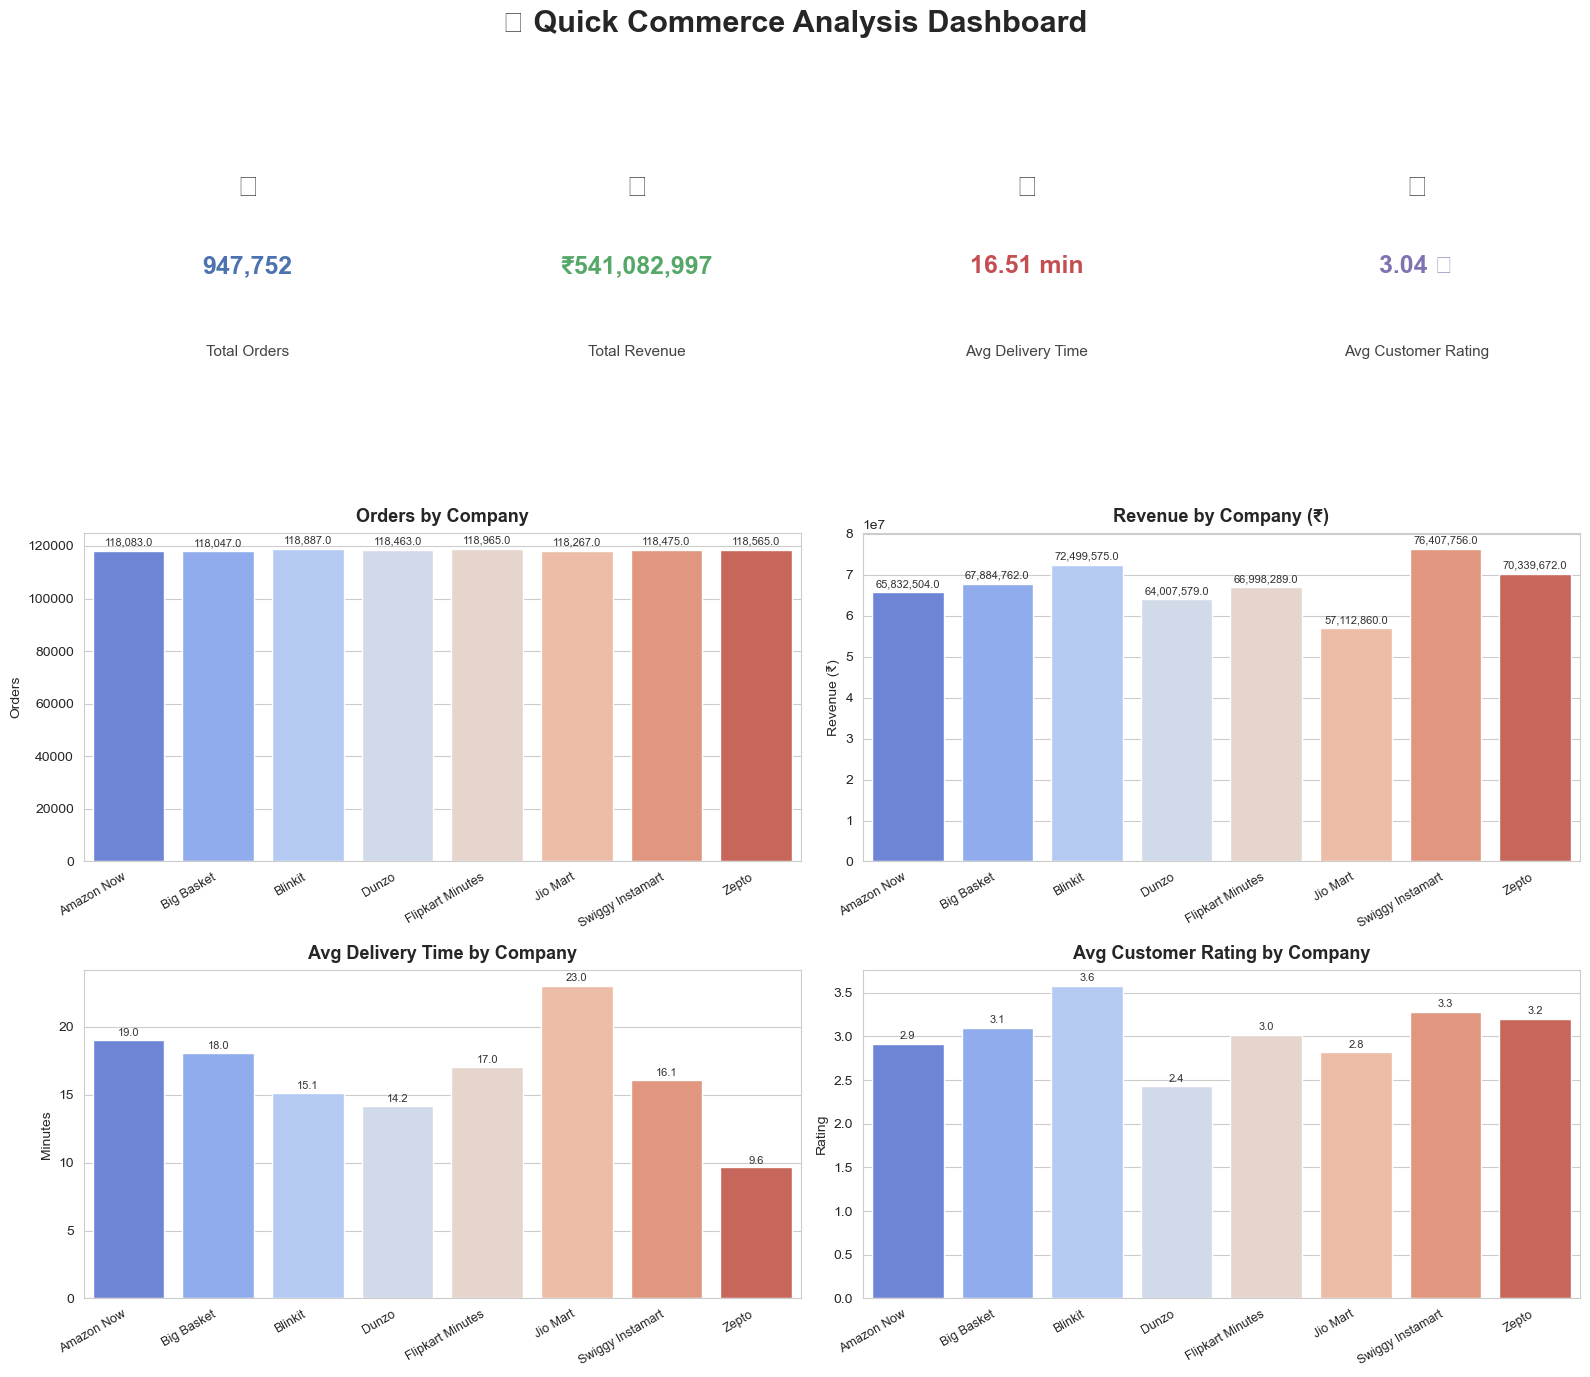

In [89]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─────────────────────────────────────────────
# Dashboard Layout — single figure
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
sns.set_style('whitegrid')

# Dashboard Title
fig.suptitle("⚡ Quick Commerce Analysis Dashboard",
             fontsize=22, fontweight='bold', y=0.98)

# ─────────────────────────────────────────────
# KPI Calculations
# ─────────────────────────────────────────────
Total_orders       = df['Order_ID'].count()
Total_revenue      = df['Order_Value'].sum()
Avg_delivery_time  = df['Delivery_Time_Min'].mean()
Avg_rating         = df['Customer_Rating'].mean()

# ─────────────────────────────────────────────
# KPI Cards  (row 0, cols 0-3)
# ─────────────────────────────────────────────
kpi_data = [
    (f"{Total_orders:,}",           "Total Orders",         "🛒", "#4C72B0"),
    (f"₹{Total_revenue:,.0f}",      "Total Revenue",        "💰", "#55A868"),
    (f"{Avg_delivery_time:.2f} min","Avg Delivery Time",    "⚡", "#C44E52"),
    (f"{Avg_rating:.2f} ⭐",        "Avg Customer Rating",  "🌟", "#8172B2"),
]

for col, (value, label, icon, color) in enumerate(kpi_data):
    ax = plt.subplot2grid((3, 4), (0, col), fig=fig)
    ax.set_facecolor(color + "22")          # light tint background
    ax.axis('off')

    # Card border
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(color)
        ax.spines[spine].set_linewidth(2)

    ax.text(0.5, 0.72, icon,  fontsize=22, ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.5, 0.48, value, fontsize=18, ha='center', va='center',
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, fontsize=11, ha='center', va='center',
            color='#444444', transform=ax.transAxes)

# ─────────────────────────────────────────────
# Company-level Metrics
# ─────────────────────────────────────────────
company_metrics = df.groupby('Company').agg(
    Orders            = ('Order_ID',          'count'),
    Revenue           = ('Order_Value',        'sum'),
    Avg_Delivery_Time = ('Delivery_Time_Min',  'mean'),
    Avg_rating        = ('Customer_Rating',    'mean')
).reset_index()

# ─────────────────────────────────────────────
# Charts  (rows 1-2, spanning 2 cols each)
# ─────────────────────────────────────────────
chart_configs = [
    ((1, 0), 'Orders',            'Orders by Company',              'Orders'),
    ((1, 2), 'Revenue',           'Revenue by Company (₹)',          'Revenue (₹)'),
    ((2, 0), 'Avg_Delivery_Time', 'Avg Delivery Time by Company',   'Minutes'),
    ((2, 2), 'Avg_rating',        'Avg Customer Rating by Company', 'Rating'),
]

for (row, col), metric, title, ylabel in chart_configs:
    ax = plt.subplot2grid((3, 4), (row, col), colspan=2, fig=fig)
    sns.barplot(
        data=company_metrics,
        x='Company', y=metric,
        palette='coolwarm', hue='Company',
        legend=False, ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=9)

    # Value labels on bars
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h * 1.01,
                f"{h:,.1f}",
                ha='center', va='bottom', fontsize=8, color='#333333'
            )

# ─────────────────────────────────────────────
# Final layout
# ─────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])   # leave room for suptitle
plt.savefig("quick_commerce_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()